#1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from xgboost import XGBClassifier, plot_importance

# **All directories are based on google colab's file structure.**

#2. Load Data

In [ ]:
!git clone https://github.com/jfung07/UCLA_Thesis
base = "/content/UCLA_Thesis/data"

Cloning into 'UCLA_Thesis'...
remote: Enumerating objects: 1800, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 1800 (delta 24), reused 78 (delta 16), pack-reused 1711 (from 1)
Receiving objects: 100% (1800/1800), 929.68 MiB | 20.91 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (1690/1690), done.


In [ ]:
df = pd.read_excel(os.path.join(base, "processed.xlsx"))

split_path = os.path.join(base, "split")
train_df = pd.read_excel(os.path.join(split_path, "train.xlsx"))
val_df = pd.read_excel(os.path.join(split_path, "val.xlsx"))
test_df = pd.read_excel(os.path.join(split_path, "test.xlsx"))

## 2a. Convert Categorical Variables

In [ ]:
cat_col = ['game', 'set_loc', 'set_receiver', 'team']
for data in [df, train_df, val_df, test_df]:
  for col in cat_col:
    data[col] = data[col].astype(str).str.strip().astype('category')


# 3. Set Loc

Others do not show up in train and test, so need to combine non starting hitters.

In [ ]:
for data in [df, train_df, val_df, test_df]:
  data['set_receiver'] = data['set_receiver'].replace(['setter1', 'outside3', 'libero', 'opposite2', 'middle3', 'ds', 'setter2'], 'other')

/tmp/ipykernel_9707/674585431.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data['set_receiver'] = data['set_receiver'].replace(['setter1', 'outside3', 'libero', 'opposite2', 'middle3', 'ds', 'setter2'], 'other')


## 3a. Data and Transforms

In [ ]:
X_train_rec = train_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
rec_train = train_df['set_receiver']
rec_train = rec_train.reset_index(drop=True)
X_val_rec = val_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
rec_val = val_df['set_receiver']
rec_val   = rec_val.reset_index(drop=True)
X_test_rec = test_df.drop(columns=['observation', 'receiver_loc', 'pass_loc', 'set_loc', 'num_block', 'set_receiver', 'kill', 'game_sex', 'level'])
rec_test = test_df['set_receiver']
rec_test  = rec_test.reset_index(drop=True)
classes = df['set_receiver'].value_counts().index.tolist()
NUM_CLASS = len(df['set_receiver'].value_counts().index.tolist())

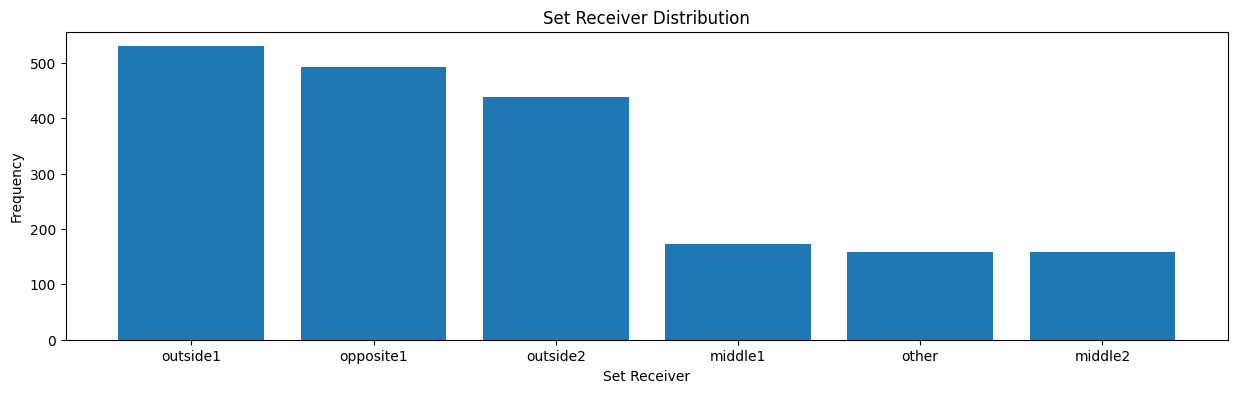

In [ ]:
nums = df['set_receiver'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Receiver")
ax.set_ylabel("Frequency")
ax.set_title("Set Receiver Distribution")
plt.show()

##3b. Configurations

In [ ]:
experiments = [
    # 0: baseline
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 1},
    # 1: smaller learning rate/more trees - better generalization
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.05, 'n_estimators': 400, 'alpha': 1},
    # 2: larger learning rate/less trees - unstable learning
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 3,
     'learning_rate': 0.2, 'n_estimators': 80, 'alpha': 1},
    # 3: smaller alpha/deeper - more flexible
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 4,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 0.5},
    # 4: larger alpha - prevent overfitting
    {'objective': 'multi:softprob', 'num_class': NUM_CLASS, 'max_depth': 5,
     'learning_rate': 0.1, 'n_estimators': 300, 'alpha': 5},
]

## 3c. Encoder

In [ ]:
le = LabelEncoder()
le.fit(rec_train)
rec_train_enc = le.transform(rec_train)
rec_val_enc = le.transform(rec_val)
rec_test_enc = le.transform(rec_test)

##3d. Performance

In [ ]:
DETERMINISTIC_ARGS = dict(
    enable_categorical=True,
    random_state=256,
    tree_method="hist",        # for repoduce
    n_jobs=1,                   # for reproduce
    sampling_method="uniform"   # for reproduce
)

In [ ]:
rec_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_rec, rec_train_enc)
  y_pred = model.predict(X_val_rec)
  acc = accuracy_score(rec_val_enc, y_pred)
  f1 = f1_score(rec_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  rec_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(rec_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))



Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3174, Val F1: 0.283
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3208, Val F1: 0.284
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3515, Val F1: 0.291
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3481, Val F1: 0.320
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.3345, Val F1: 0.266

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob          6          4           0.10           300    0.5      3  0.348123 0.320492
multi:softprob          6          3           0.20            80    1.0      2  0.351536 0.290843
multi:softprob          6          4           0.05           400    1.0      1  0.320819 0.283800
multi:softprob          6          4           0.10           300    1.0      0  0.317406 0.282951
multi:softprob          6          5           0.10           300    5.0      4  0.334471 0.265560


The small alpha model performs the best with a 0.348123 accuracy and F1 of 0.320492.  The large learning rate follows closely with a lower f1 score but a higher accuracy. The large alpha model has the worst f1 but an accuracy in the middle.

##3e. Importance and Performance

###3e2. Importance Plots

#### Accuracy Gain

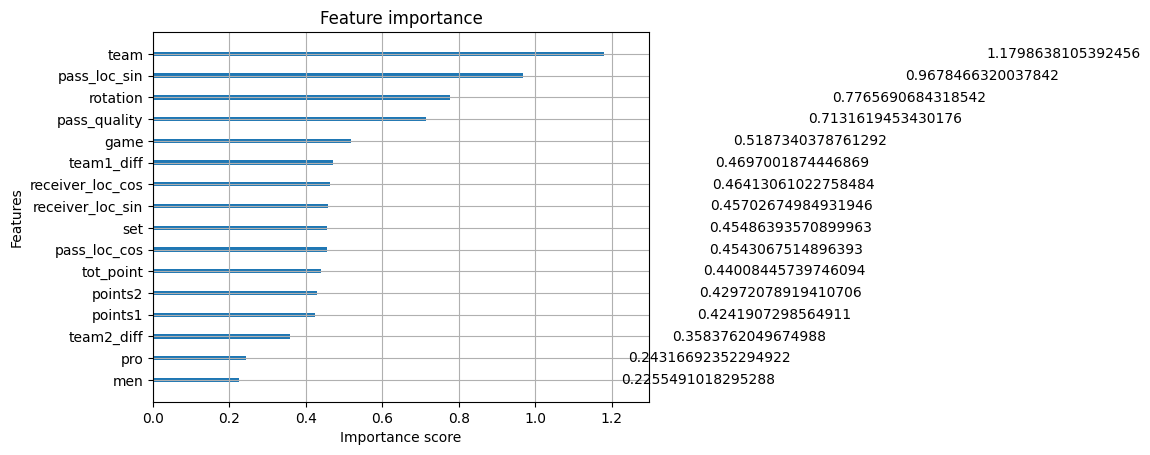

In [ ]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

*Team inproves accuracy the most followed by pass_quality and second touch net distance then rotation.  The least important are gender and points.  Many variables account for similar variability, so might investigate simpler model.*

#### Weight Importance

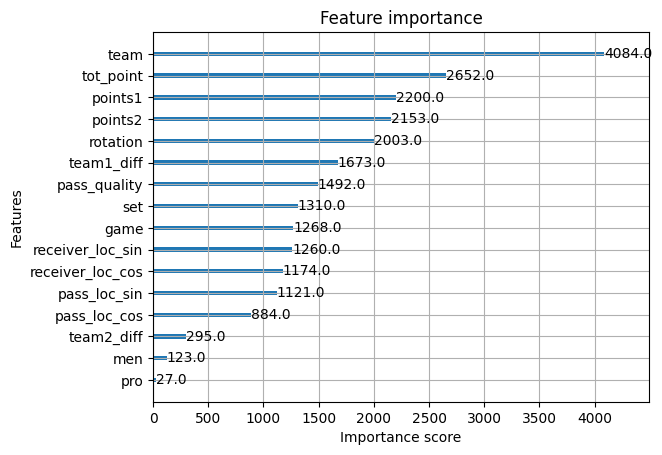

In [ ]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

*The model uses team, and the point features to split the most frequently as well as rotation and pass_quality.  On the other hand level, gender, and receiver location are the least important.*

*The plots indicate that one point variable maybe sufficient, and level and gender may have negligiable effects.  Investigate a simpler model with total points, pass quality, pass_loc_sin, team, and rotation as the features tend to appear in the top half of each importance plot.  Similarly, many features have overlapping characteristics, so might investigate a model with total points(rep point features), pass_quality(representing first and second touch), team(rep game unique), set(game stage)*

#### Shap Values

In [ ]:
#del shap_values

explainer = shap.Explainer(best_model)
sv = explainer(X_test_rec)

print("sv shape:", sv.values.shape)
print("X_train_rec shape:", X_test_rec.shape)

sv shape: (293, 16, 6)
X_train_rec shape: (293, 16)


In [ ]:
print(le.classes_)

['middle1' 'middle2' 'opposite1' 'other' 'outside1' 'outside2']


Middle 1

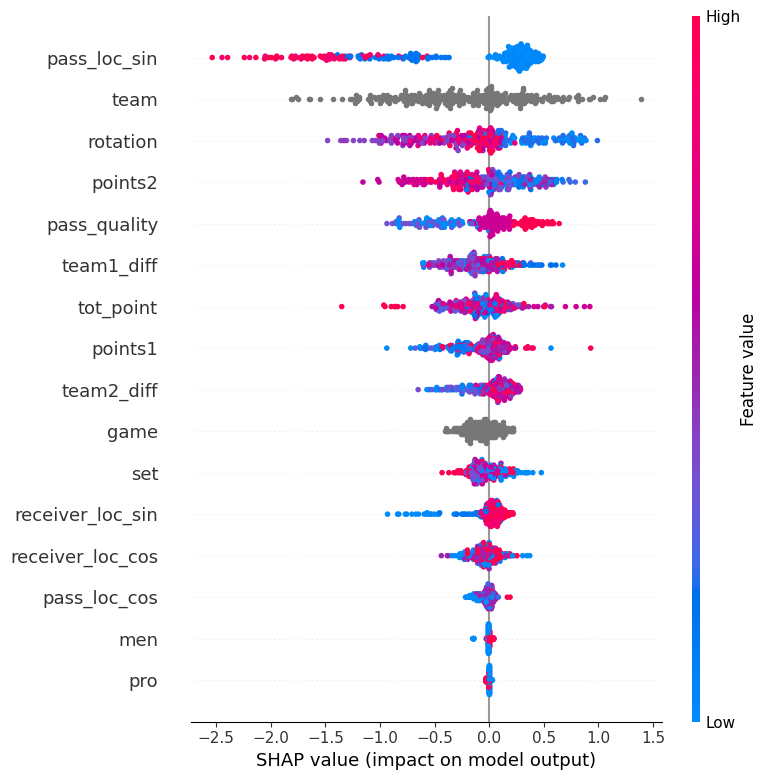

In [ ]:
sv_class0 = sv.values[:, :, 0]   # shape (1366, 16)
shap.summary_plot(sv_class0, X_test_rec)


*how far the second touch occurs from the net and the quality of the first touch are the most important predictors for a 1 set followed by the team and rotation.  The least significant predictors are level, gender, set number, and lateral location of the second touch after accounting for all other variables with low magnitude SHAP values.  Directionally, second touches closer to the net are more likely to be 1 sets; similarly, as the pass quality increases, the set is more likely to be a 1.  When the setter is in the back row, the set is more likely to be a 1 location.  Men tend to set a 1 location more than women. In the beginning of a set(points1 inc) the set is more likely to be a 1, conversely, as the game progresses(set inc) the set is more likely to be a 1, but the association is weaker.  Additionally, the closer the first touch occurs relative to the net, the set is less likely to be a 1 location.*

Middle 2

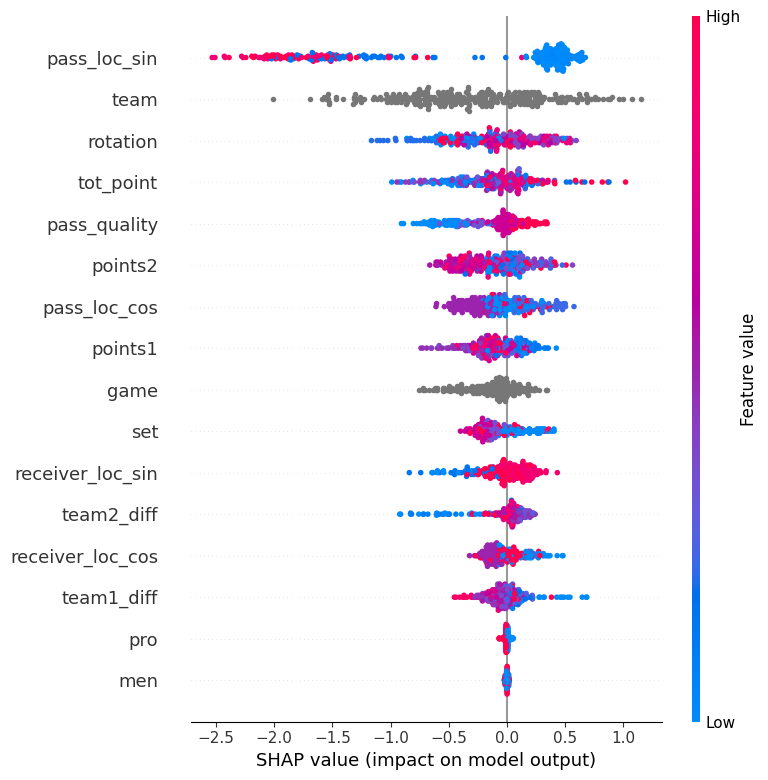

In [ ]:
sv_class1 = sv.values[:, :, 1]   # shape (1366, 16)
shap.summary_plot(sv_class1, X_test_rec)

*Team, game and points for each team are the most important.  When the setter is in the front, a 2 is more likely than in the back.  When the receiver is on the right side rather than the left, the set is less likely to be a 2.  When the setter is on the right, the set is more likely to be a 2 compared to the left.  When the pass is low quality, the set is more likely to be a 2 than when the pass is good.  Professionals tend to set 2s less than d1 players.  The when the first touch is close to the net, the set is more likely to be a 2 than when the first touch is far.  When the second touch is far from the net, a two is more likely than when it is close.  Men tend to set 2s more than women.*

Opposite 1

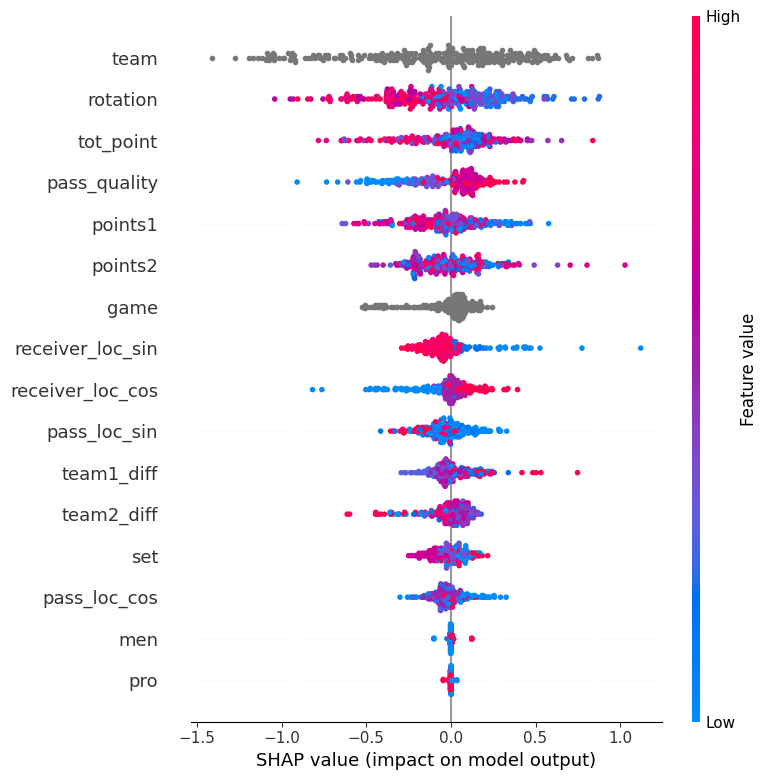

In [ ]:
sv_class2 = sv.values[:, :, 2]   # shape (1366, 16)
shap.summary_plot(sv_class2, X_test_rec)

*Team is the most influential.  3 sets are more likely when the setter is in the back row.  The further, the set is from the net, the more likely a 3 set is.  The point variables contradict each other.  Where 3s are more common when team 1 has many points, but less likely when both teams have many points and indistinguisable based on point differential.  The closer the first set is to the net, 3 is less likely. Level, gender, and lateral orientation of the first touch are the least important.*

Other

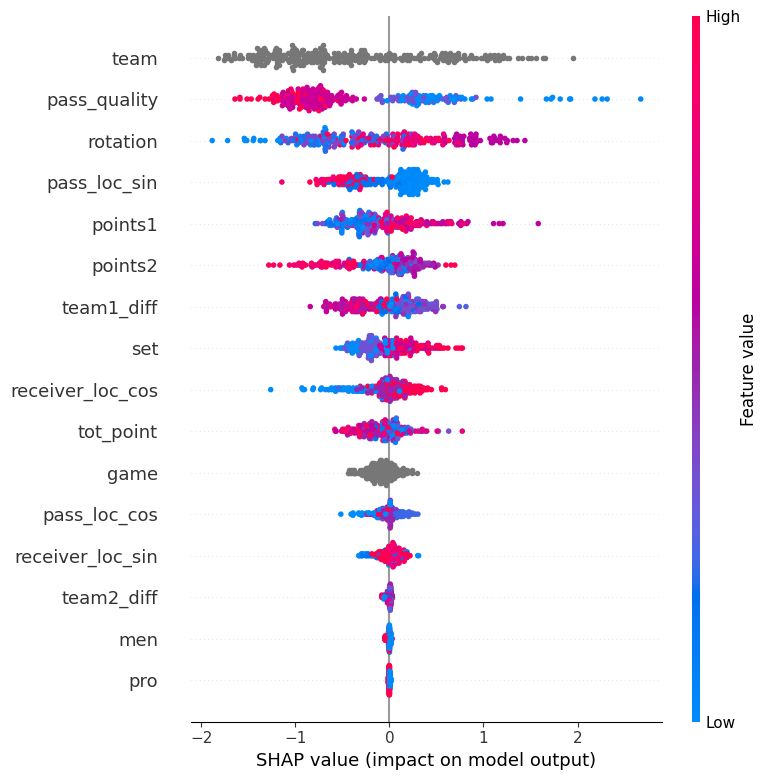

In [ ]:
sv_class3 = sv.values[:, :, 3]   # shape (1366, 16)
shap.summary_plot(sv_class3, X_test_rec)

*Pass quality, team, and rotation are the most influential variables, while level, gender, game stage(game,set_, and level are the least influential.  Low pass quality are less likely to be a 4 set.  When the setter is in the front row, a four set is more likely.  The further the second touch occurs from the net, the more likely the set is to be a four location.   As the set progresses, a 4 set becomes more likely.  The more left the first touch occurs, the less likely a four set is.   As the first touch gets closer to the net, the more likely a 4 set is.*

Outside1

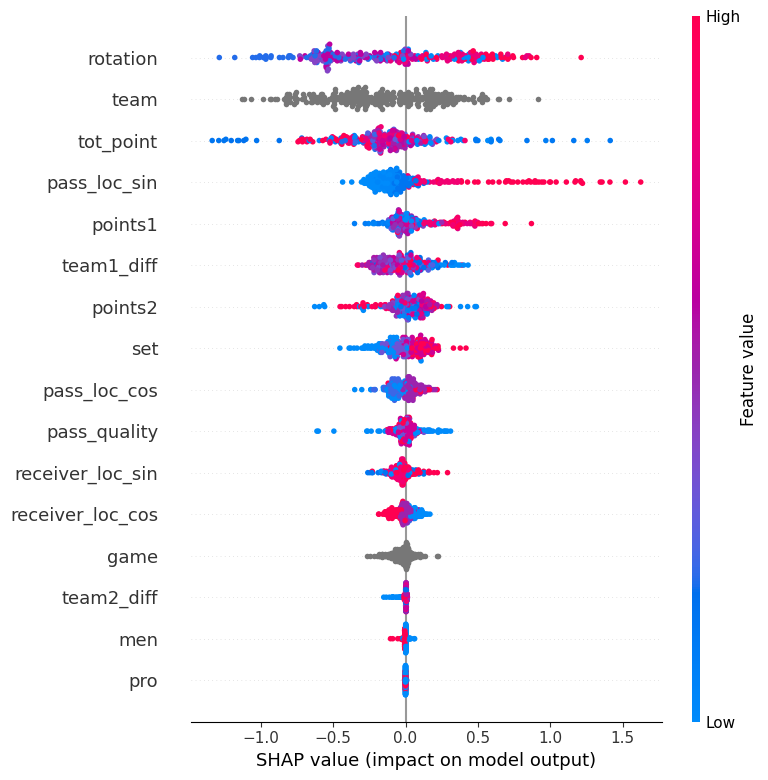

In [ ]:
sv_class4 = sv.values[:, :, 4]   # shape (1366, 16)
shap.summary_plot(sv_class4, X_test_rec)

*Rotation, team, how far the second touch occurs from the net, and the quality are the most influential variables.  The gender, level and right and left orientation of touches are the least importan.  When the right side hitter is in the back row, a 5 set is far lass likely.  The closer the second touch occurs to the net the more likely a 5 set is.  The lower the quality of the pass, the lower the likelihood of a 5 set is.  5 set are less likely in the early game(set low) but more frequent at the beginning of the set(low tot).  The closer the first touch occurs, the more likely a 5 set is.  The more right the second touch occurs, the less likely a 5 set is.*

Outside2

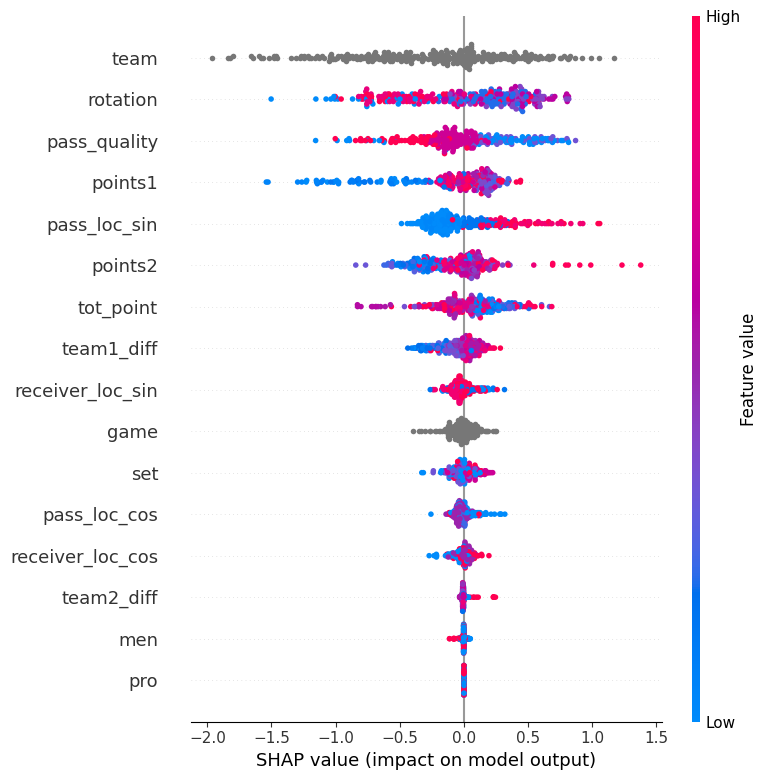

In [ ]:
sv_class5 = sv.values[:, :, 5]   # shape (1366, 16)
shap.summary_plot(sv_class5, X_test_rec)

*Pass quality, how far the second touch occurs from the net, and the team are the most influential variables, while the level and gender are the least.  First touch quality is inversely related to the likelihood of an A location set.  Similarly, the further the second touch is from the net, the more likely an A set is.  Sets on the right tend to not be A location sets.  The later the game is, the more likely an A set is.  When the first touch occurs on the right ride, an A set is less likely than from the middle.*

Global

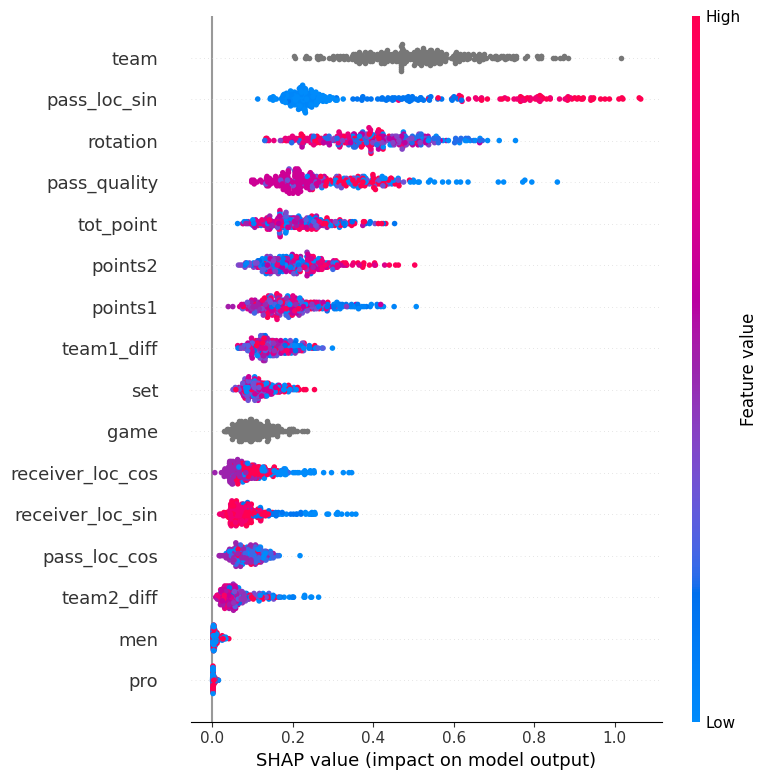

In [ ]:
sv_global = np.abs(sv.values).mean(axis=2)   # shape (1366, 16)
shap.summary_plot(sv_global, X_test_rec)


*Bad passes have the most impact(blue dots on the far right). Team is influential.  Second touch occuring further from the net is influential.  Total points especially, late game is influential.  Game is influential.*

### 3e3. Test Performance

In [ ]:
y_pred = best_model.predict(X_test_rec)
acc = accuracy_score(rec_test_enc, y_pred)
f1 = f1_score(rec_test_enc, y_pred, average = "macro")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(rec_test_enc,
                            y_pred,
                            target_names = le.classes_))

Test accuracy: 0.4061433447098976, Test F1 score: 0.3671161662844202

Classification Report
              precision    recall  f1-score   support

     middle1       0.35      0.27      0.30        26
     middle2       0.29      0.17      0.22        23
   opposite1       0.32      0.48      0.38        66
       other       0.50      0.31      0.38        26
    outside1       0.53      0.47      0.50        86
    outside2       0.42      0.42      0.42        66

    accuracy                           0.41       293
   macro avg       0.40      0.35      0.37       293
weighted avg       0.42      0.41      0.40       293



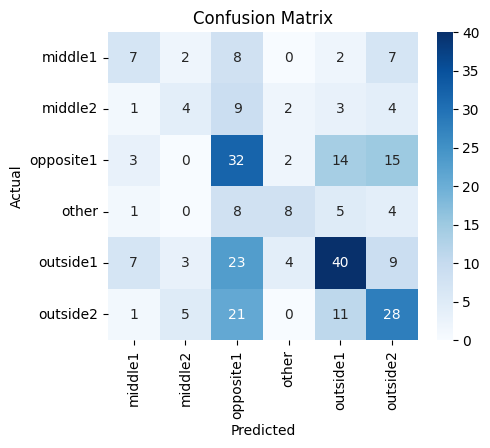

In [ ]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(rec_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Predicts correct label the most within each prediction class

## 7d. Feature selection

In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_test_rec.columns,
    "importance": np.abs(sv_global).mean(axis=0)
}).sort_values("importance", ascending=False)

print(feature_importance)

             feature  importance
9               team    0.516759
13      pass_loc_sin    0.417391
7           rotation    0.396070
8       pass_quality    0.298404
4          tot_point    0.215468
1            points2    0.212354
0            points1    0.200973
2         team1_diff    0.152353
5                set    0.123035
6               game    0.106915
10  receiver_loc_cos    0.101937
11  receiver_loc_sin    0.095417
12      pass_loc_cos    0.088731
3         team2_diff    0.066776
14               men    0.007873
15               pro    0.003590


1.   Using a 0.2 threshold, I will look at a model with team, rotation, pass_loc_sin, pass_quality, tot_point, points2, and points1.
2.   Based on columns, will investigate a the most relevant feature in group.  The chosen model includes pass_loc_sin, rotation, team, tot_point.  The groups are first to second touch:[pass_quality, pass_loc, receiver_loc], dem:[team, game, men, pro], game stage: [tot_pt, team1, team2, point1/2, set], rotation.





### 7d1. 0.2 Threshhold

#### Data

In [ ]:
X_train_rec = train_df[['team', 'rotation', 'pass_loc_sin', 'pass_quality', 'tot_point', 'points1', 'points2']]
rec_train = train_df['set_receiver']
rec_train = rec_train.reset_index(drop=True)
X_val_rec = val_df[['team', 'rotation', 'pass_loc_sin', 'pass_quality', 'tot_point', 'points1', 'points2']]
rec_val = val_df['set_receiver']
rec_val = rec_val.reset_index(drop=True)
X_test_rec = test_df[['team', 'rotation', 'pass_loc_sin', 'pass_quality', 'tot_point', 'points1', 'points2']]
rec_test = test_df['set_receiver']
rec_test = rec_test.reset_index(drop=True)
classes = df['set_receiver'].value_counts().index.tolist()
NUM_CLASS = len(df['set_receiver'].value_counts().index.tolist())

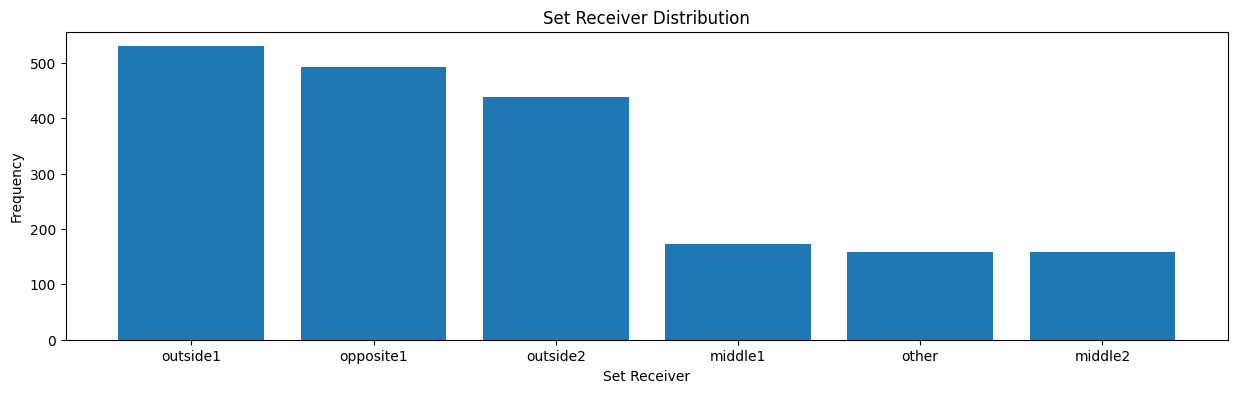

In [ ]:
nums = df['set_receiver'].value_counts()
fig, ax = plt.subplots(figsize = (15,4))
ax.bar(nums.index.astype(str), nums.values)
ax.set_xlabel("Set Receiver")
ax.set_ylabel("Frequency")
ax.set_title("Set Receiver Distribution")
plt.show()

####Model

In [ ]:
rec_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_rec, rec_train_enc)
  y_pred = model.predict(X_val_rec)
  acc = accuracy_score(rec_val_enc, y_pred)
  f1 = f1_score(rec_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  rec_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_loc_results = pd.DataFrame(rec_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_loc_results.sort_values(by="f1", ascending = False).to_string(index=False))


Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3242, Val F1: 0.280
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3379, Val F1: 0.295
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3652, Val F1: 0.309
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3276, Val F1: 0.279
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.3106, Val F1: 0.223

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob          6          3           0.20            80    1.0      2  0.365188 0.308851
multi:softprob          6          4           0.05           400    1.0      1  0.337884 0.294996
multi:softprob          6          4           0.10           300    1.0      0  0.324232 0.280409
multi:softprob          6          4           0.10           300    0.5      3  0.327645 0.278960
multi:softprob          6          5           0.10           300    5.0      4  0.310580 0.223140


Best model is the large learning rate model with acc = 0.365188 and f1 = 0.308851, with the small learning rate close behind.  Similar performance(higher acc lower f1) with a simpler model, so retain this simpler model.

#### Gain

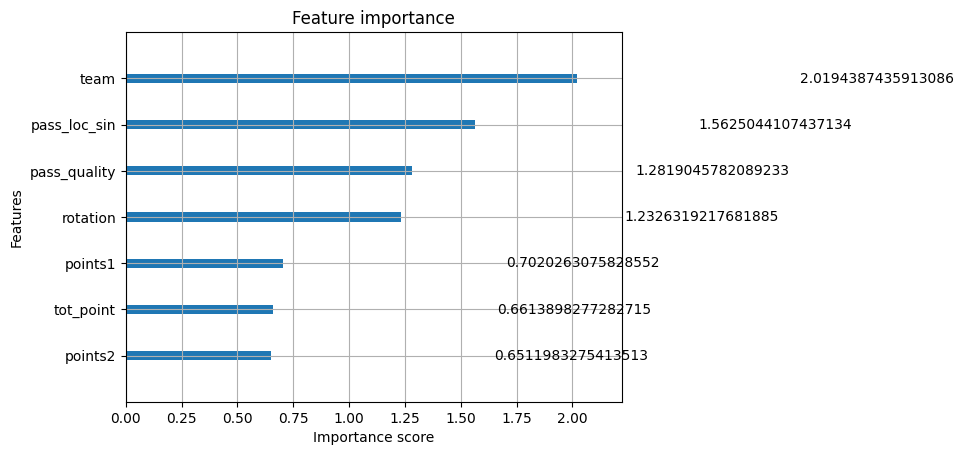

In [ ]:
plot_importance(best_model, importance_type = 'gain')
plt.show()

Team is the most important followed by the pass quality vars, then rotation, then point vars.

#### Weight

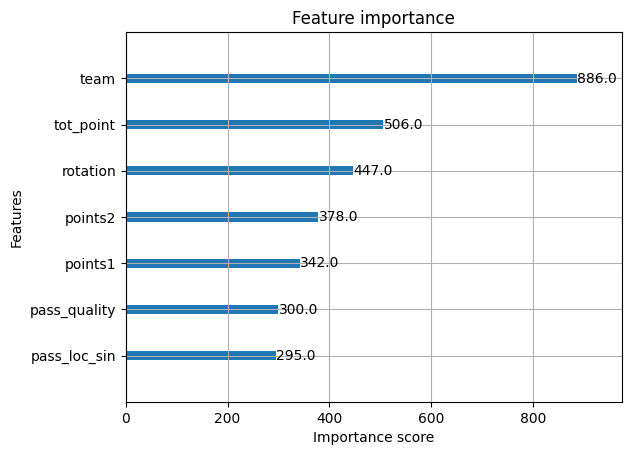

In [ ]:
plot_importance(best_model, importance_type = 'weight')
plt.show()

Team is the most important for splitting, foloowed by total points, then rotation.  The two pass features are the least important.  Flipped from acc gain except team.

#### Shap

In [ ]:
explainer = shap.Explainer(best_model)
sv = explainer(X_test_rec)

print("sv shape:", sv.values.shape)
print("X_train_loc shape:", X_test_rec.shape)
print(le.classes_)

sv shape: (293, 7, 6)
X_train_loc shape: (293, 7)
['middle1' 'middle2' 'opposite1' 'other' 'outside1' 'outside2']


Middle1

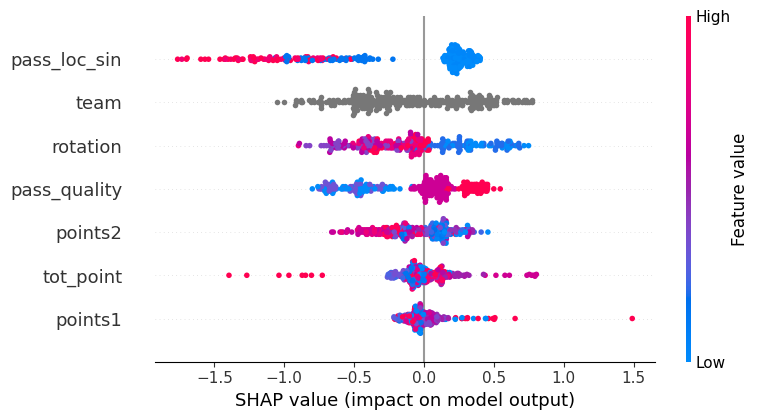

In [ ]:
sv_class0 = sv.values[:, :, 0]   # shape (1366, 16)
shap.summary_plot(sv_class0, X_test_rec)

When the second touch occurs far from the net, the set is less likely to be a middle 1 set.  Team is the second most important followed by rotation.  When the setter is in the back row, a set is moe likely to be for the middle 1 than when the setter is in the back row.  Next is pass quality, where better passes are more likely to be middle 1 sets than bad passes.  Last are the point features.  As team 2 scores, a middle 1 set is less likely, but as team 1 scores, a middle 1 set is more likely.

Middle2

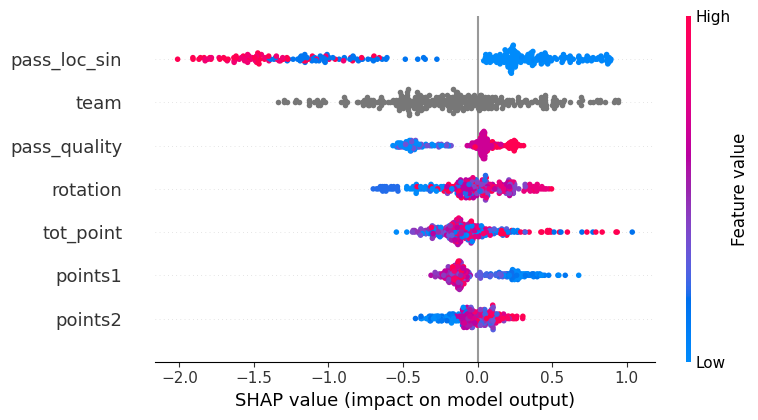

In [ ]:
sv_class1 = sv.values[:, :, 1]   # shape (1366, 16)
shap.summary_plot(sv_class1, X_test_rec)

Similar to middle 1, middle 2's feature importance order is second touch net distance followed by team, then switches rotation, and pass quality then finally points.  However, some relation directions flip.  Sets are less likely to go to the middle 2 when the setter is in the back row as they are not in the game yet.  For low point values for team 1, a middle 2 set is more likely, while the converse is true for team 2.  The pass quality and distance relations remain the same.

Opposite1

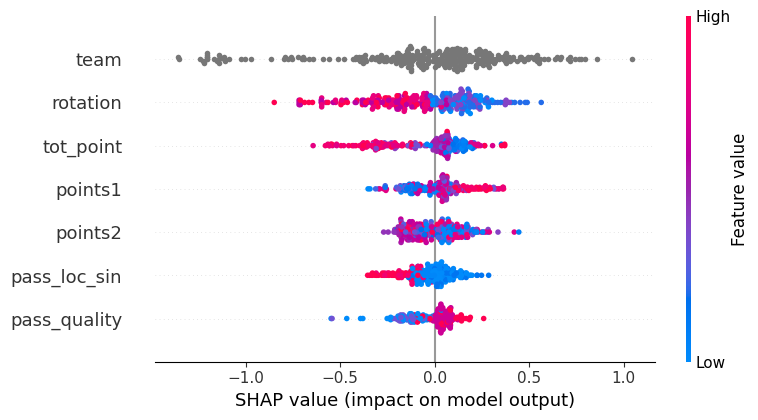

In [ ]:
sv_class2 = sv.values[:, :, 2]   # shape (1366, 16)
shap.summary_plot(sv_class2, X_test_rec)

Team again is the most important feature followed by rotation, where an opposite set is less likely when the setter is in the front row as the opposite is no longer in the front row.  As the game progresses, an opposite set is less likely, however as team 1 scores more points, an opposite set is more likely.  Second touches further from the net are less likely to be opposite sets.  High quality passes are more likely to result in opposite sets.

Other

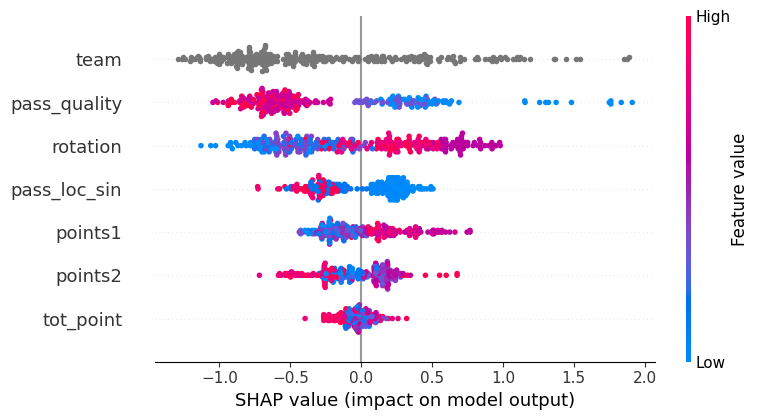

In [ ]:
sv_class3 = sv.values[:, :, 3]   # shape (1366, 16)
shap.summary_plot(sv_class3, X_test_rec)

Team again is the most important predictor followed by pass quality, then rotation, then second touch net distance then points.  An other set is more likely when the pass quality is low.  When the setter is in the front row, an other set is more likely.  Passes closer to the net are more likely to be an other set.  As team 1 scores, an other set becomes more likely.

Outside1

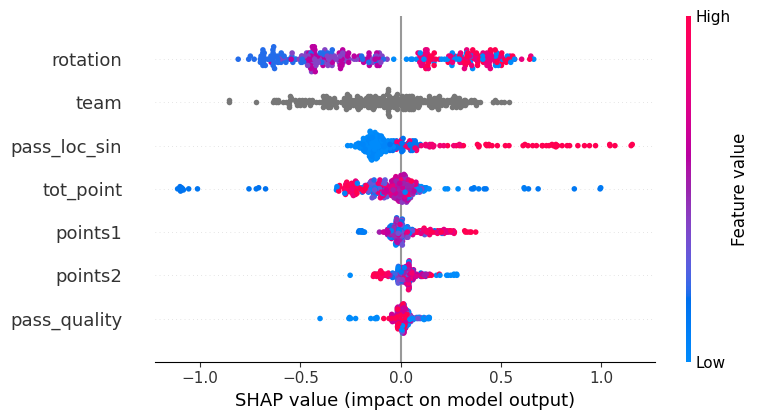

In [ ]:
sv_class4 = sv.values[:, :, 4]   # shape (1366, 16)
shap.summary_plot(sv_class4, X_test_rec)

Rotation is now the most important feature followed by team, where the set is less likely to be for the outside 1 when the setter is in the back row as they are only in the front row for one rotation when the setter is in the back row.  The further the second touch occurs from the net, the more likely the set is for the outside 1.  As the pass quality decreases, the set is less likely to be for the outside 1.

Outside2

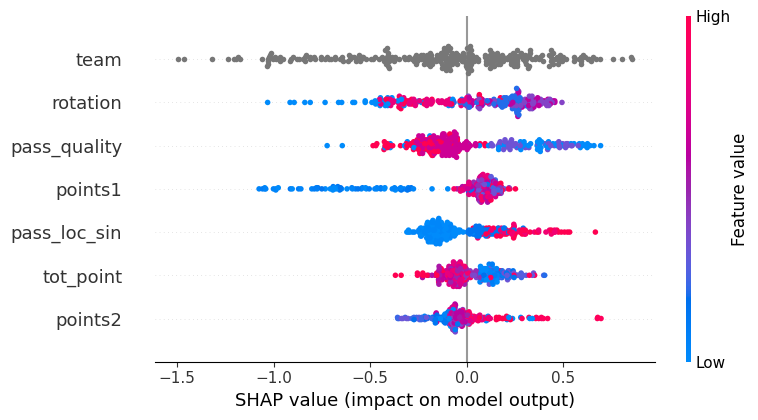

In [ ]:
sv_class5 = sv.values[:, :, 5]   # shape (1366, 16)
shap.summary_plot(sv_class5, X_test_rec)

Importance is surprisingly different for outside 2.  Team is the most important followed by rotation.  When the setter is in the back row, the set is less likely to be for the outside2.  Low pass quality is also less likely to result in a outside 2 set.  When team 1 has few points, the set is less likely to go to the outside 2.  As the second touch moves further from the net, the likelihood of an outside 2 set increases.  As the game progresses, an outside 2 set is less likely.

Global

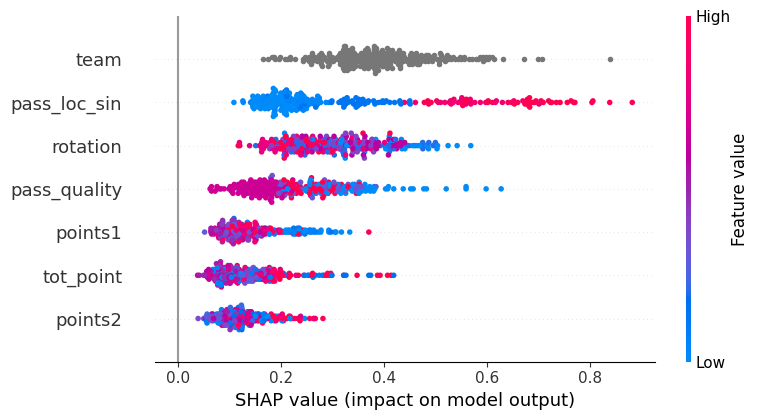

In [ ]:
sv_global = np.abs(sv.values).mean(axis=2)   # shape (1366, 16)
shap.summary_plot(sv_global, X_test_rec)

Similar to acc increase plot, but rotation becomes more important.  Team and rotation tend to be the most important in every class with points toward the bottom.

####Test performance

In [ ]:
y_pred = best_model.predict(X_test_rec)
acc = accuracy_score(rec_test_enc, y_pred)
f1 = f1_score(rec_test_enc, y_pred, average = "macro")
print(f"Test accuracy: {acc}, Test F1 score: {f1}")
print("\nClassification Report")
print(classification_report(rec_test_enc,
                            y_pred,
                            target_names = le.classes_))

Test accuracy: 0.3890784982935154, Test F1 score: 0.32508647547561326

Classification Report
              precision    recall  f1-score   support

     middle1       0.27      0.15      0.20        26
     middle2       0.27      0.13      0.18        23
   opposite1       0.30      0.39      0.34        66
       other       0.46      0.23      0.31        26
    outside1       0.48      0.52      0.50        86
    outside2       0.41      0.45      0.43        66

    accuracy                           0.39       293
   macro avg       0.36      0.31      0.33       293
weighted avg       0.39      0.39      0.38       293



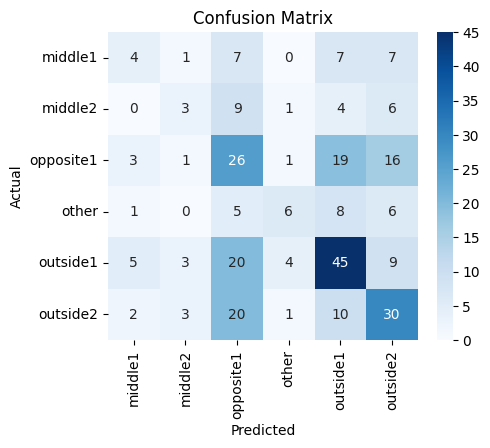

In [ ]:
labels = le.classes_
plt.figure(figsize=(5,4))
cm = confusion_matrix(rec_test_enc, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = labels, yticklabels = labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Similar to full model, but more prediction variation.

### 7d1. Group select

#### Data

In [ ]:
X_train_rec = train_df[['pass_loc_sin', 'rotation', 'team', 'tot_point']]
rec_train = train_df['set_receiver']
rec_train = rec_train.reset_index(drop=True)
X_val_rec = val_df[['pass_loc_sin', 'rotation', 'team', 'tot_point']]
rec_val = val_df['set_receiver']
rec_val = rec_val.reset_index(drop=True)
X_test_rec = test_df[['pass_loc_sin', 'rotation', 'team', 'tot_point']]
rec_test = test_df['set_receiver']
rec_test = rec_test.reset_index(drop=True)
classes = df['set_receiver'].value_counts().index.tolist()
NUM_CLASS = len(df['set_receiver'].value_counts().index.tolist())

####Model

In [ ]:
rec_results = []
best_model = None
best_f1 = -1
print(f"Starting Grid Search on {len(experiments)} configurations...\n")
for i, conf in enumerate(experiments):
  model = XGBClassifier(**DETERMINISTIC_ARGS, **conf)
  model.fit(X_train_rec, rec_train_enc)
  y_pred = model.predict(X_val_rec)
  acc = accuracy_score(rec_val_enc, y_pred)
  f1 = f1_score(rec_val_enc, y_pred, average = "macro")
  res = conf.copy()
  res['index'] = i
  res['accuracy'] = acc
  res['f1'] = f1
  rec_results.append(res)
  print(f"Exp {i+1}:  LR = {conf['learning_rate']},  alpha = {conf['alpha']} ->  Val acc: {acc:.4f}, Val F1: {f1:.3f}")
  if f1 > best_f1:
    best_f1 = f1
    best_model = model

df_rec_results = pd.DataFrame(rec_results)
print("\n" + "="*40)
print(" Final Leaderboard by F1")
print("="*40)
# sort best to worst
print(df_rec_results.sort_values(by="f1", ascending = False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1:  LR = 0.1,  alpha = 1 ->  Val acc: 0.3311, Val F1: 0.312
Exp 2:  LR = 0.05,  alpha = 1 ->  Val acc: 0.3311, Val F1: 0.295
Exp 3:  LR = 0.2,  alpha = 1 ->  Val acc: 0.3379, Val F1: 0.285
Exp 4:  LR = 0.1,  alpha = 0.5 ->  Val acc: 0.3311, Val F1: 0.304
Exp 5:  LR = 0.1,  alpha = 5 ->  Val acc: 0.3447, Val F1: 0.261

 Final Leaderboard by F1
     objective  num_class  max_depth  learning_rate  n_estimators  alpha  index  accuracy       f1
multi:softprob          6          4           0.10           300    1.0      0  0.331058 0.311963
multi:softprob          6          4           0.10           300    0.5      3  0.331058 0.304173
multi:softprob          6          4           0.05           400    1.0      1  0.331058 0.295125
multi:softprob          6          3           0.20            80    1.0      2  0.337884 0.284842
multi:softprob          6          5           0.10           300    5.0      4  0.344710 0.261484


Baseline model performs the best. Acc = 0.331058 ad f1 = 0.311963, higher f1 but lower accuracy than the original reduced model and lower in both than original, so retain the original reduced model.